### Research Question & setup
In this project, I want to determine which symptom is the best indicator for distinguishing between a normal cough caused by a cold and a cough caused by COVID-19.

In [ ]:
import pandas as pd
import json
import glob
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import librosa
import librosa.display
import numpy as np
from scipy.signal import butter, lfilter
from pathlib import Path

# Suppress all deprecation warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#### Import csv data & Filtering
filter data based off cough_detected and existence of expert label

In [11]:
work_dir = os.getcwd()
csv_path = f"{work_dir}/metadata_compiled.csv"
audio_path1 = f"{work_dir}/coughvid_20211012"
audio_path2 = f"D:/uniDev/coughvid_20211012"
#audio_path = f"{work_dir}/../08_coughvid"

audio_path = audio_path1 if os.path.exists(audio_path1) else audio_path2
all_files = os.listdir(audio_path)

# load csv
df = pd.read_csv(csv_path, index_col=0)
print(f"total datapoints in csv: {len(df)}")

# filter for cough_detected
df_clean = df[df['cough_detected'] >= 0.8].copy()
print(f"datapoints with cough_detected (>= 0.8): {len(df_clean)}")

# extract expert labelled datapoints
expert_cols = [col for col in df_clean.columns if any(f'_{i}' in col for i in range(1, 5))]
df_expert = df_clean[df_clean[expert_cols].notna().any(axis=1)].copy()
print(f"datapoints with expert labels: {len(df_expert)}")

total datapoints in csv: 34434
datapoints with cough_detected (>= 0.8): 18544
datapoints with expert labels: 2481


### Data exploration

#### Metadata Analysis

In [3]:
df.head()
#df_expert.head()

,uuid,datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,status,...,quality_4,cough_type_4,dyspnea_4,wheezing_4,stridor_4,choking_4,congestion_4,nothing_4,diagnosis_4,severity_4
0,00014dcc-0f06-4c27-8c7b-737b18a2cf4c,2020-11-25T18:58:50.488301+00:00,0.0155,48.9,2.4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00039425-7f3a-42aa-ac13-834aaa2b6b92,2020-04-13T21:30:59.801831+00:00,0.9609,31.3,34.8,15.0,male,False,False,healthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0007c6f1-5441-40e6-9aaf-a761d8f2da3b,2020-10-18T15:38:38.205870+00:00,0.1643,NaN,NaN,46.0,female,False,False,healthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00098cdb-4da1-4aa7-825a-4f1b9abc214b,2021-01-22T22:08:06.742577+00:00,0.1133,47.4,9.4,66.0,female,False,False,healthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0009eb28-d8be-4dc1-92bb-907e53bc5c7a,2020-04-12T04:02:18.159383+00:00,0.9301,40.0,-75.1,34.0,male,True,False,healthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Completeness of all column

In [4]:
# Calculate number of NaN values per column
nan_counts = df_clean.isna().sum().to_frame(name='NaN Count')

# Calculate percentage of NaN values
nan_counts['Percentage'] = (nan_counts['NaN Count'] / len(df_clean) * 100).round(2)

# Sort by NaN count descending
nan_counts = nan_counts.sort_values(by='NaN Count', ascending=False)

print("--- Missing Values (NaN) per Column ---")
print(nan_counts)

--- Missing Values (NaN) per Column ---
                       NaN Count  Percentage
diagnosis_3                17889       96.47
severity_3                 17889       96.47
cough_type_3               17889       96.47
quality_3                  17881       96.42
wheezing_3                 17881       96.42
stridor_3                  17881       96.42
choking_3                  17881       96.42
dyspnea_3                  17881       96.42
congestion_3               17881       96.42
nothing_3                  17881       96.42
diagnosis_1                17876       96.40
wheezing_1                 17876       96.40
dyspnea_1                  17876       96.40
cough_type_1               17876       96.40
stridor_1                  17876       96.40
quality_1                  17876       96.40
choking_1                  17876       96.40
congestion_1               17876       96.40
nothing_1                  17876       96.40
severity_1                 17876       96.40
cough_type_2   

status_SSL is missing roughly 50% of the time and we have no deeper explanation on how it was created, therefore it can be dsicarded later on

##### Data distribution

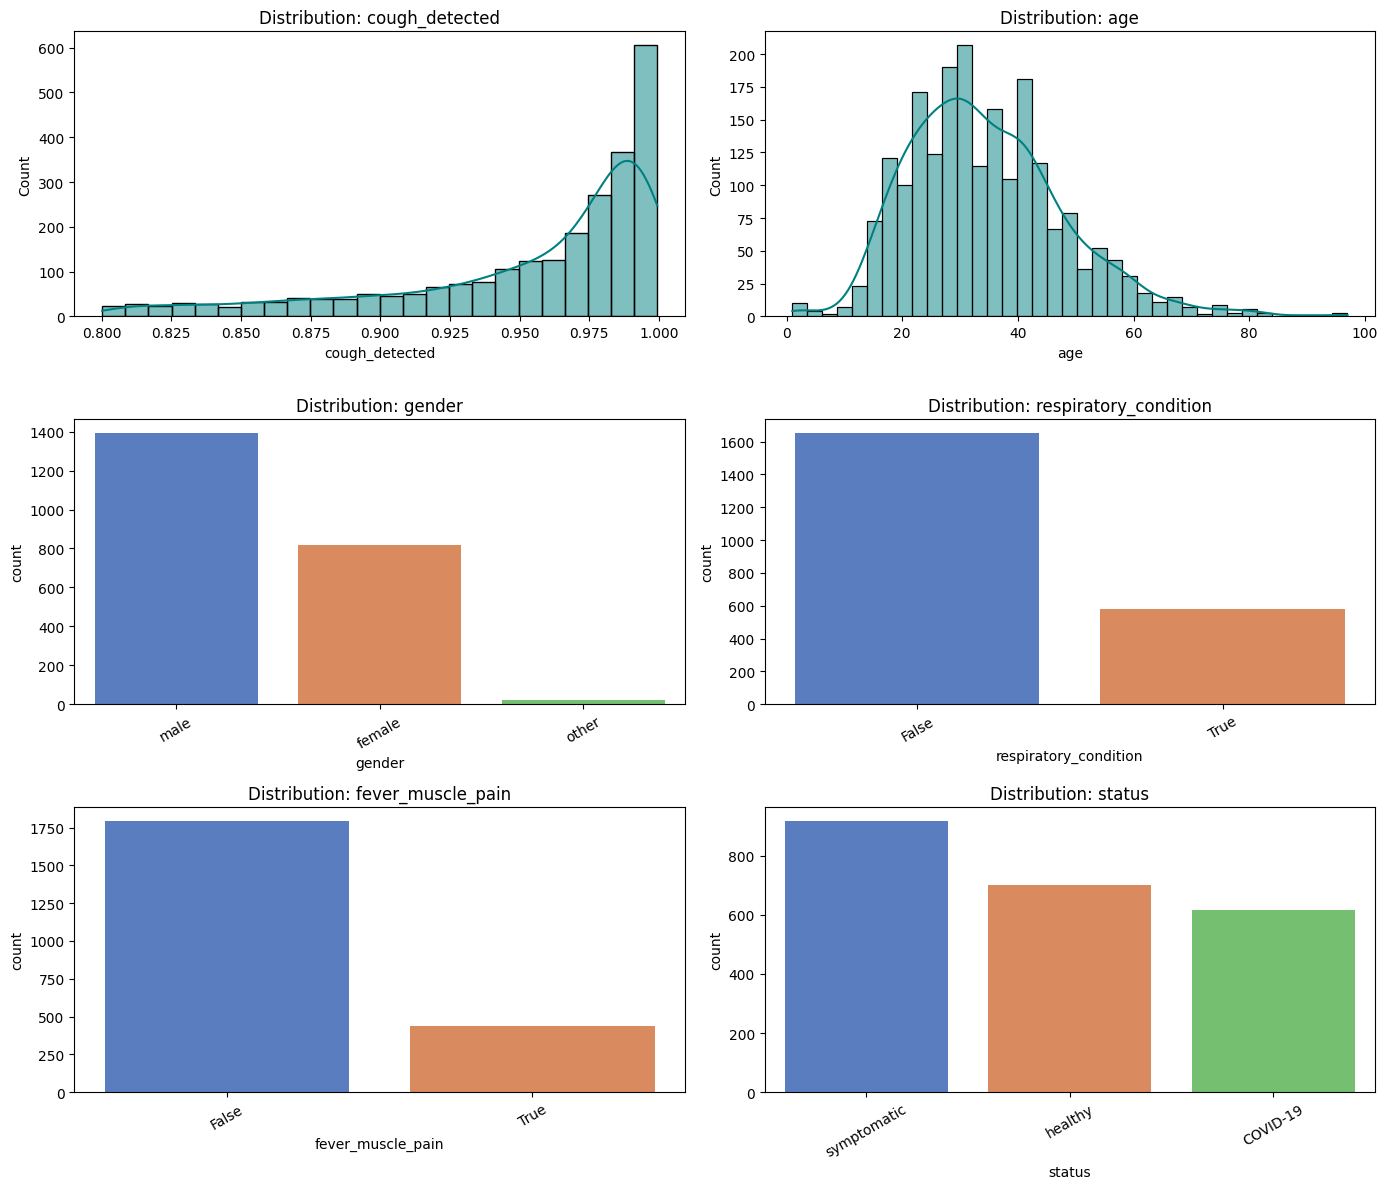

In [5]:
# 1. Identify columns to exclude
# We exclude status_SSL and anything ending in _1, _2, _3, or _4
regex_expert = r'(_[1-4])$'
cols_to_plot = [c for c in df_expert.columns 
                if not re.search(regex_expert, c) 
                and c not in ['status_SSL', 'uuid', 'datetime', 'latitude', 'longitude']]

# 2. Setup plotting grid
n_cols = 2
n_rows = (len(cols_to_plot) + 1) // n_cols
plt.figure(figsize=(14, 4 * n_rows))

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Drop NaNs for plotting
    data_subset = df_expert[col].dropna()
    
    if data_subset.empty:
        plt.text(0.5, 0.5, f'No data for {col}', ha='center')
        continue

    # Determine plot type based on data type
    if df_expert[col].dtype in ['float64', 'int64']:
        # Numerical Distribution
        sns.histplot(data_subset, kde=True, color='teal')
        plt.title(f'Distribution: {col}')
    else:
        # Categorical Distribution
        # Use value_counts to handle booleans and strings nicely
        order = data_subset.value_counts().index
        sns.countplot(x=data_subset, order=order, palette='muted')
        plt.xticks(rotation=30)
        plt.title(f'Distribution: {col}')

plt.tight_layout()
plt.show()

##### Age distribution

status
healthy        10132
symptomatic     2683
COVID-19         720
Name: count, dtype: int64


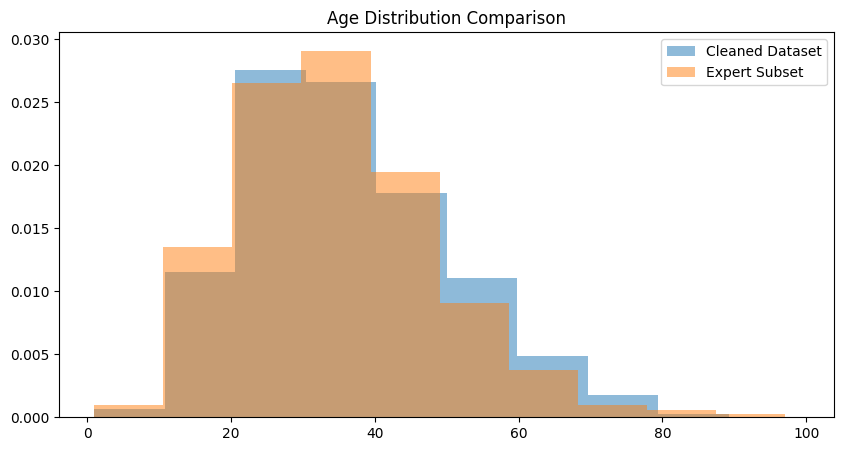

In [6]:
# overview of the full cleaned dataset
print(df_clean['status'].value_counts()) 

plt.figure(figsize=(10, 5))
plt.hist(df_clean['age'].dropna(), alpha=0.5, label='Cleaned Dataset', density=True)
plt.hist(df_expert['age'].dropna(), alpha=0.5, label='Expert Subset', density=True)
plt.title('Age Distribution Comparison')
plt.legend()
plt.show()

##### expert labeled distributions

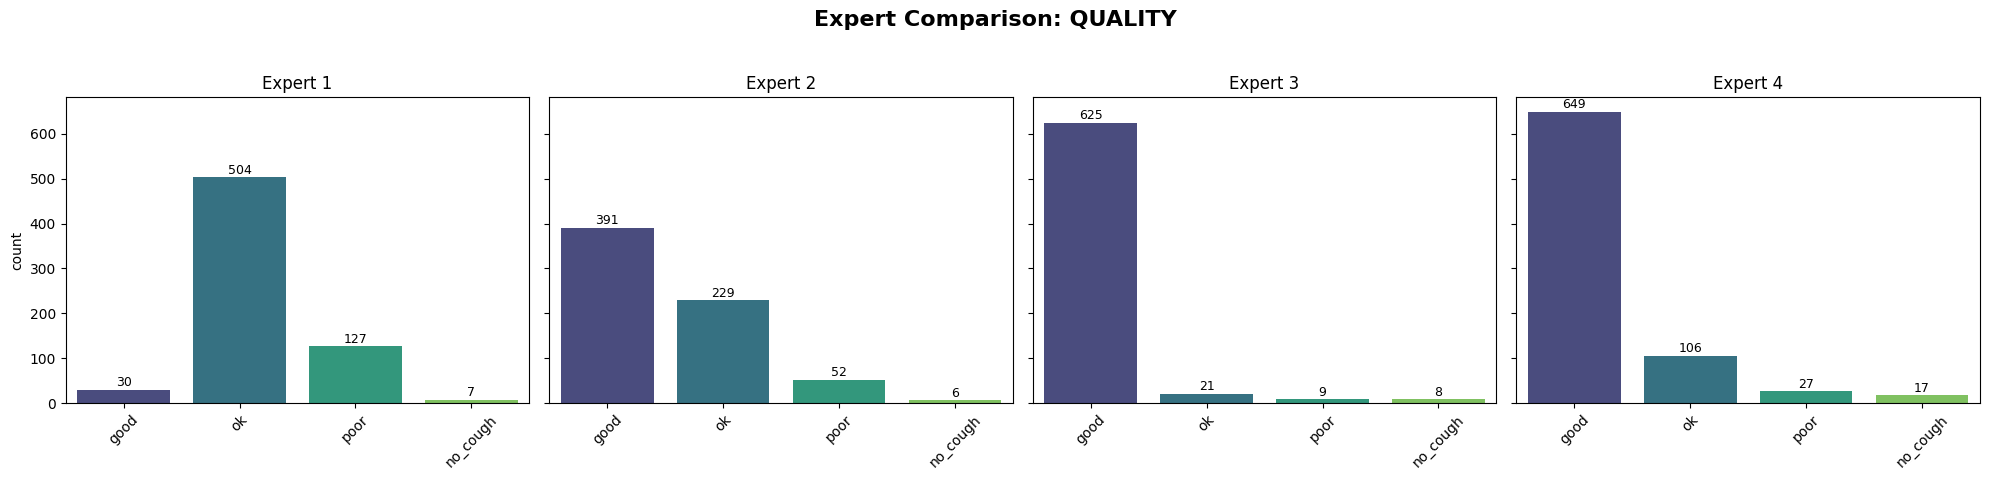

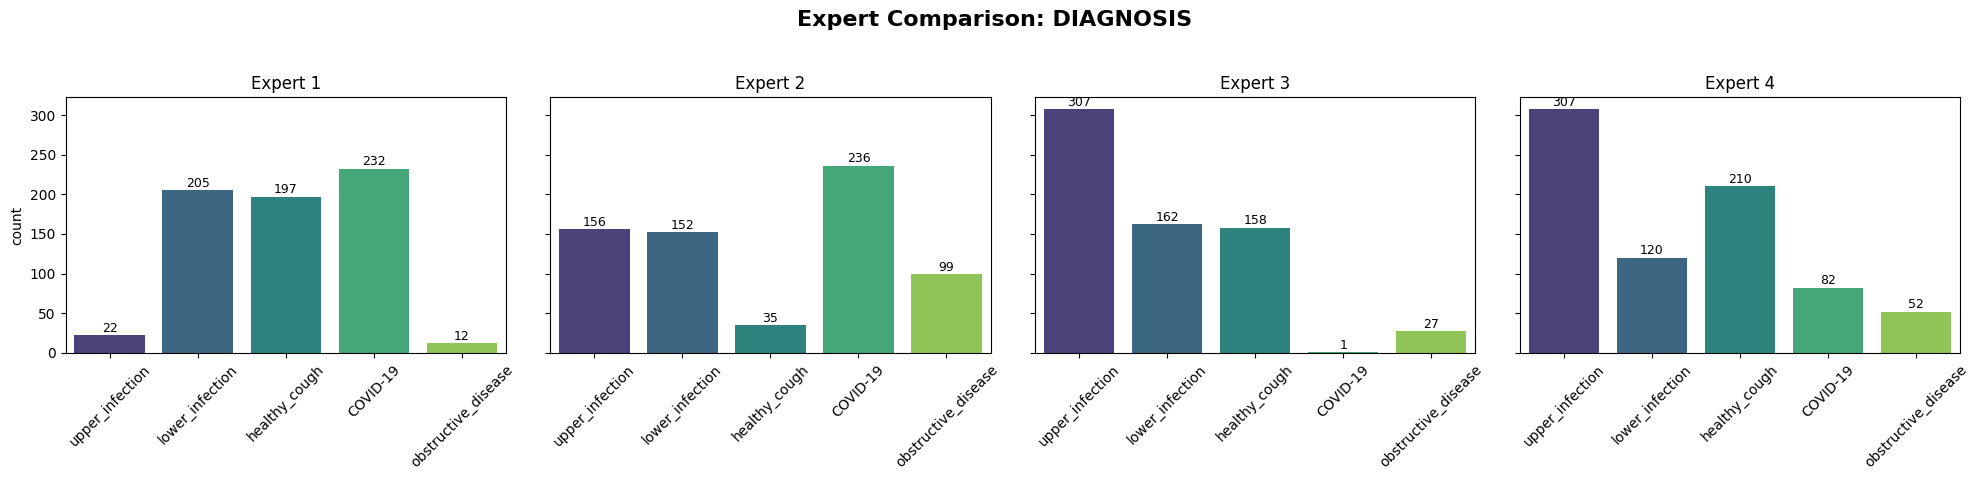

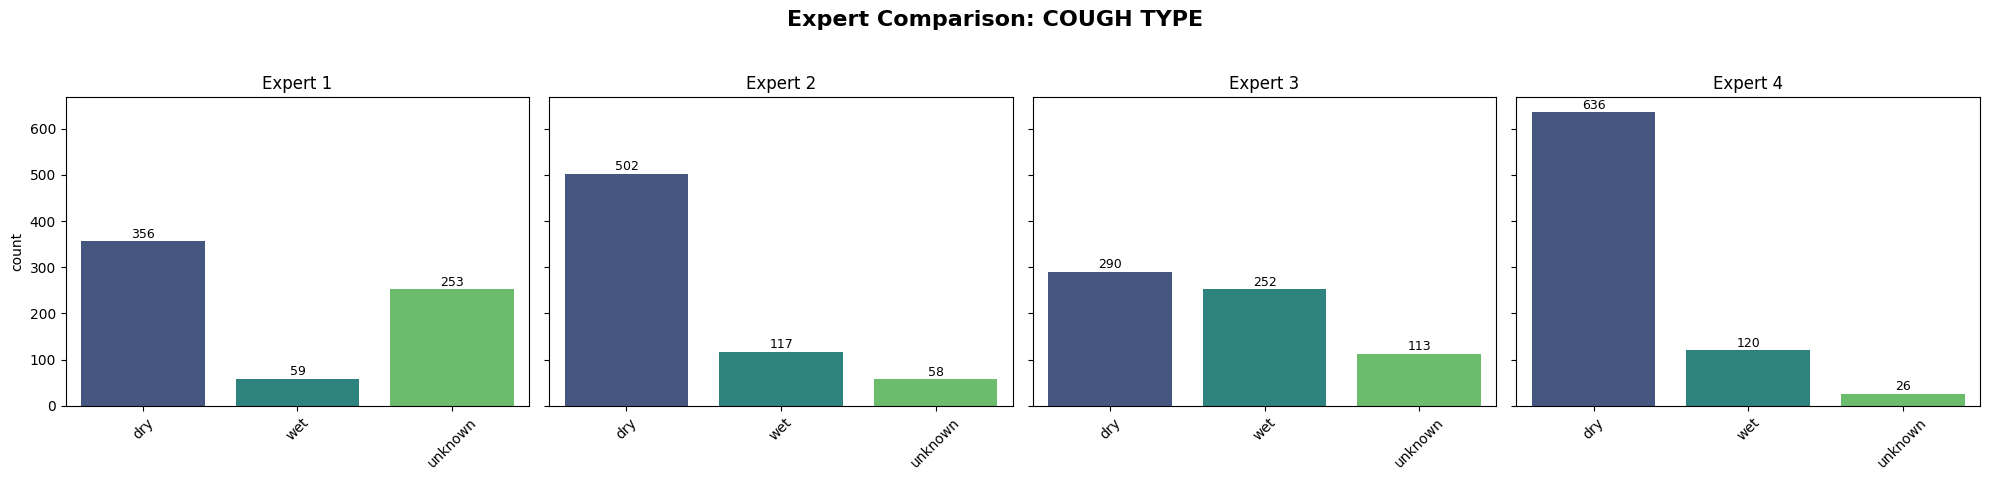

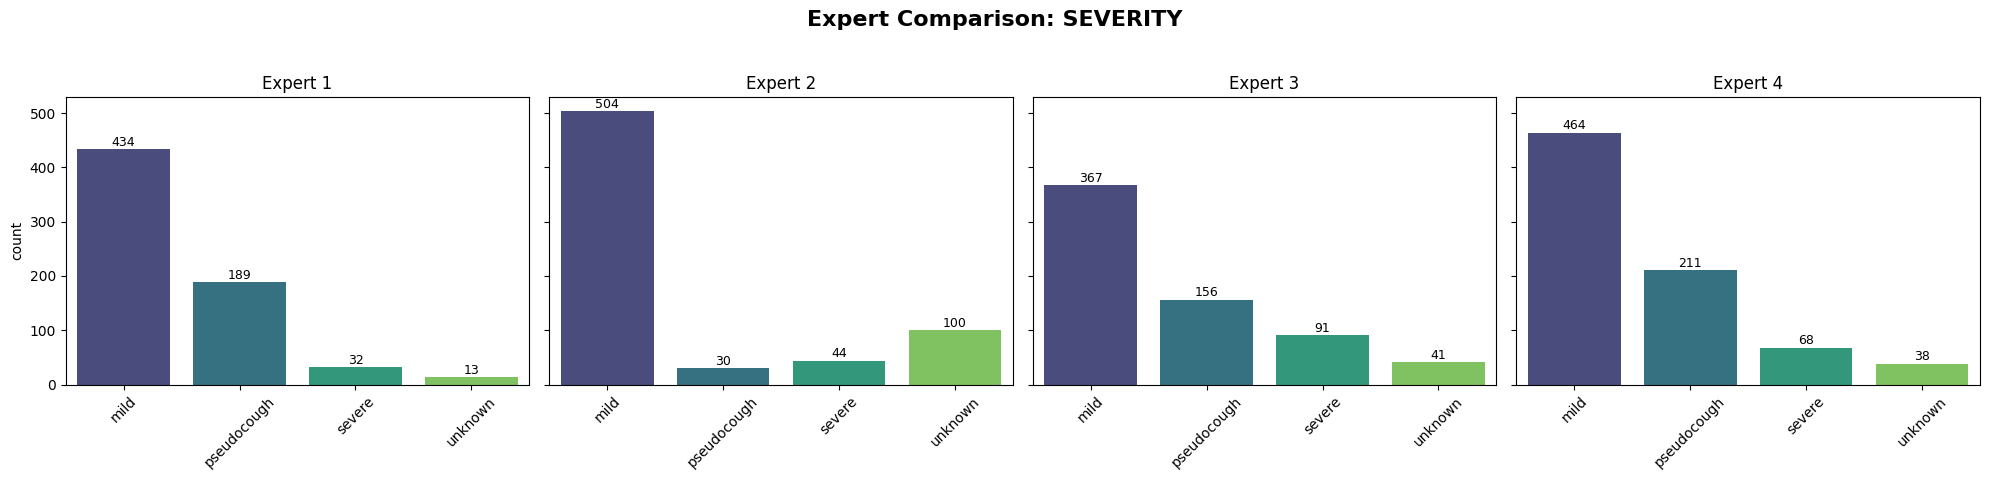

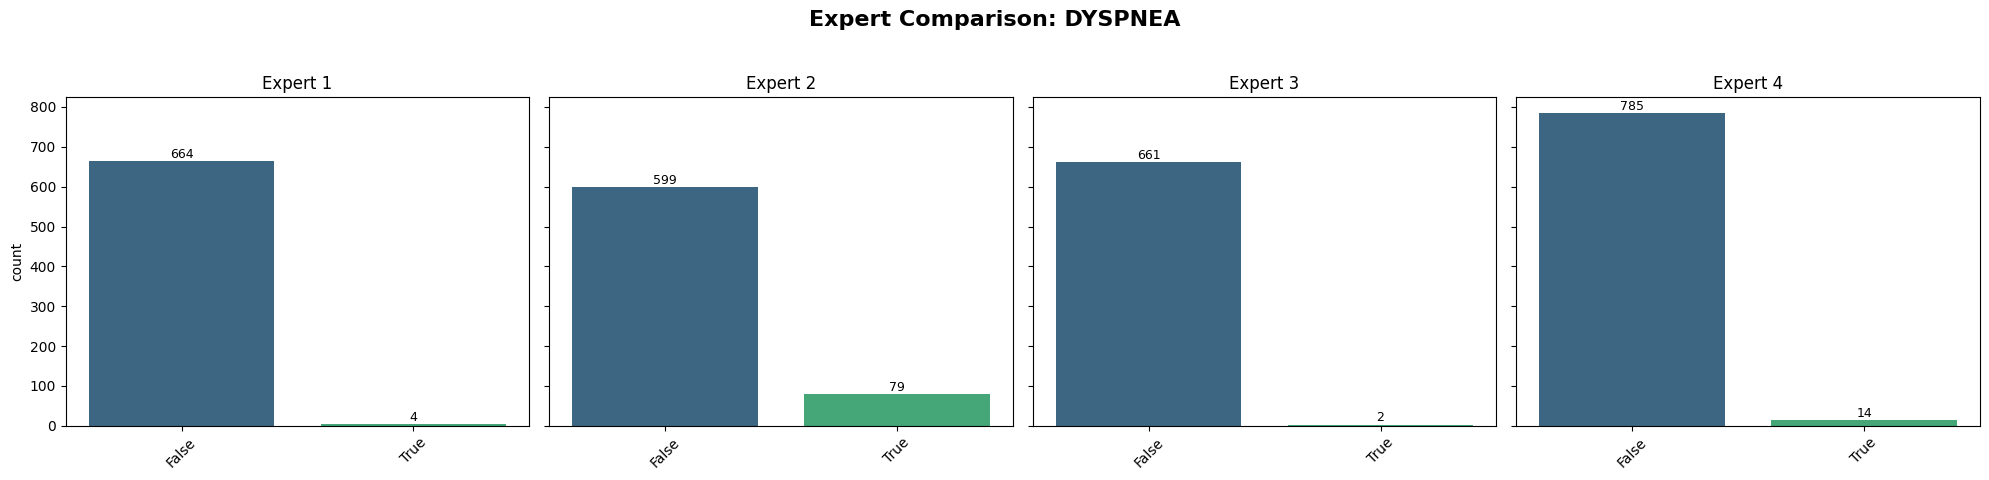

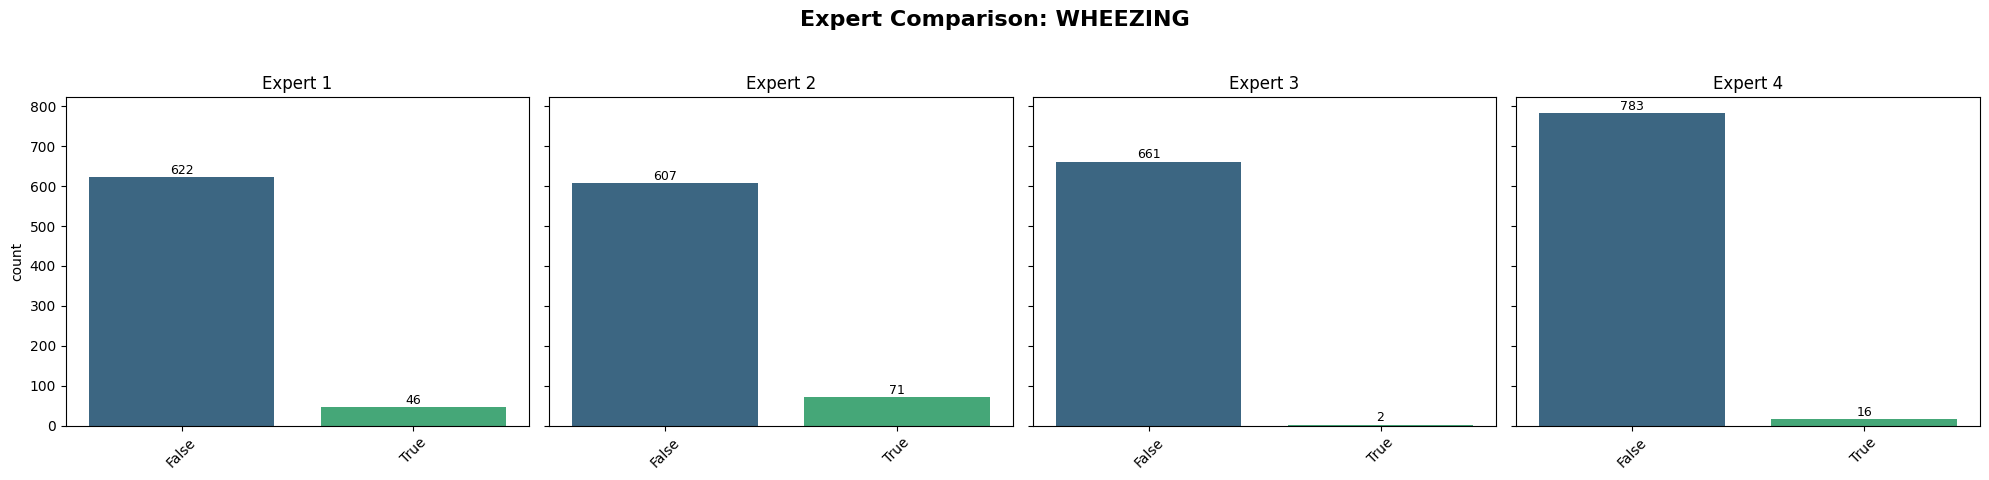

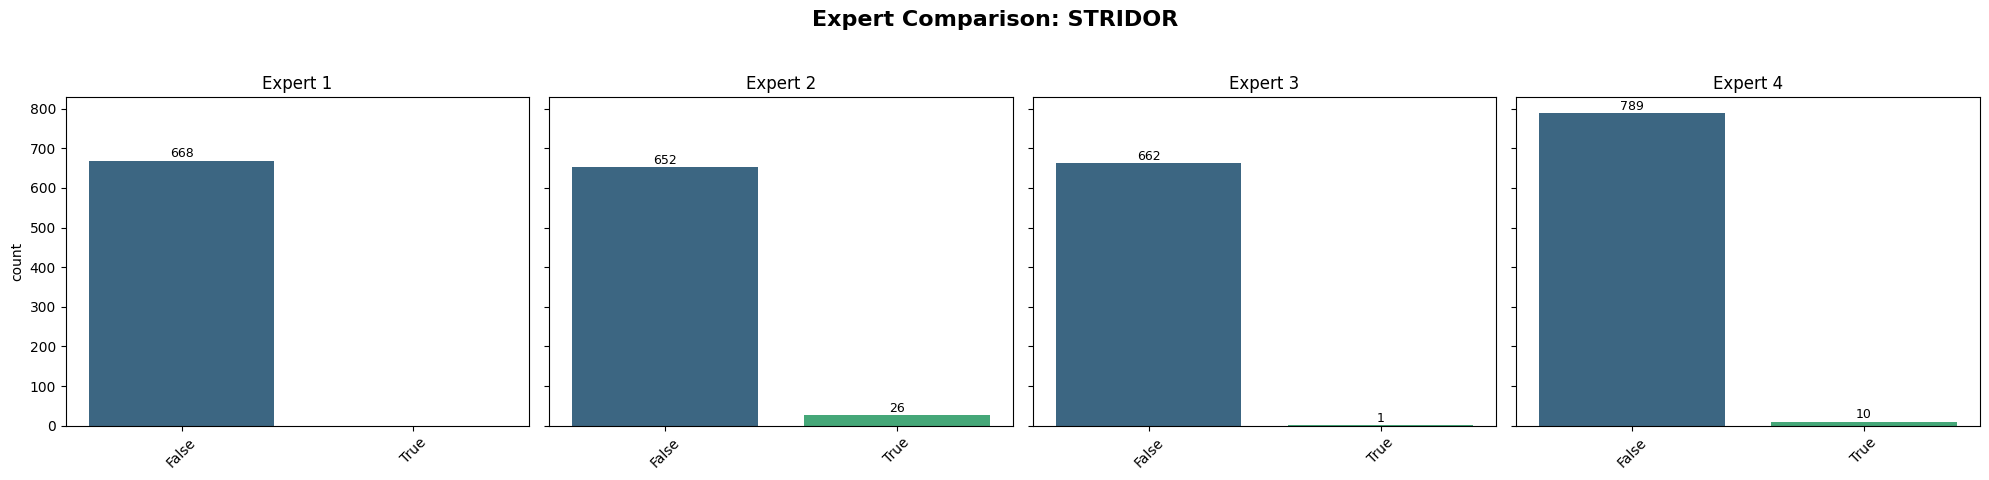

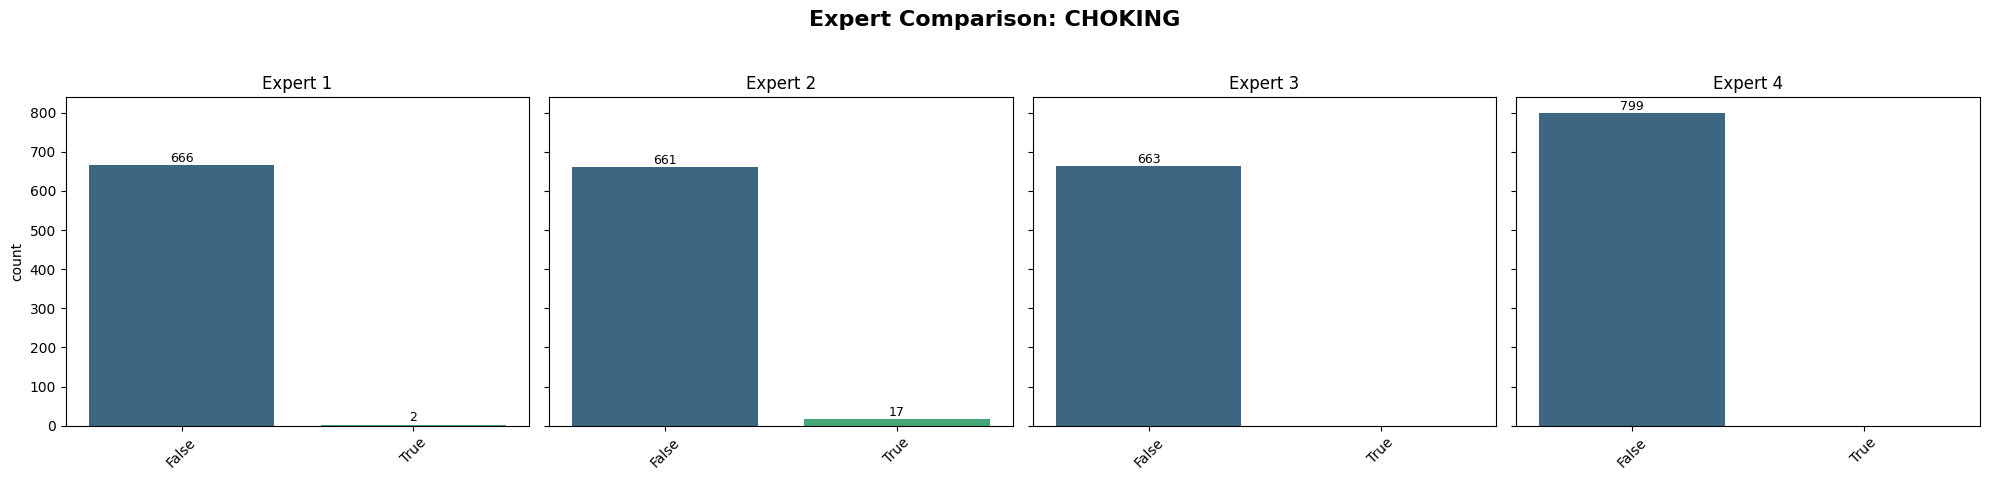

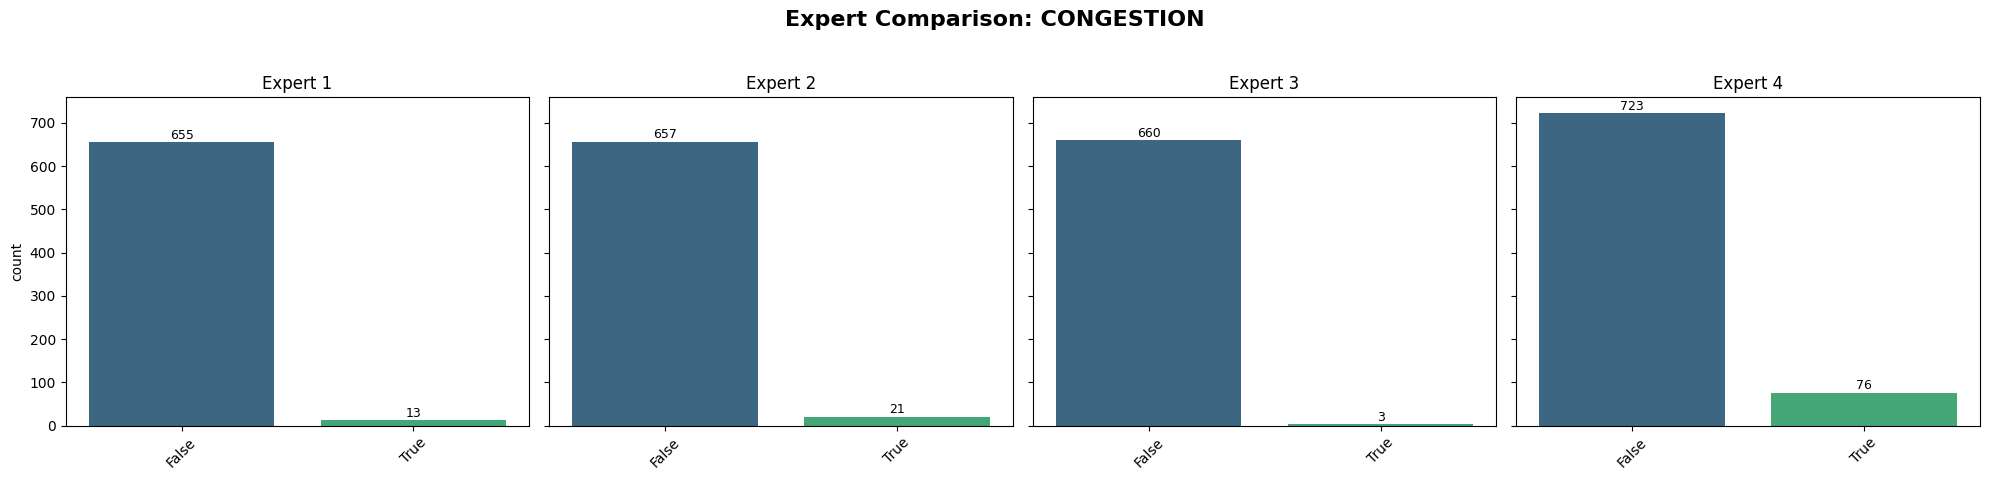

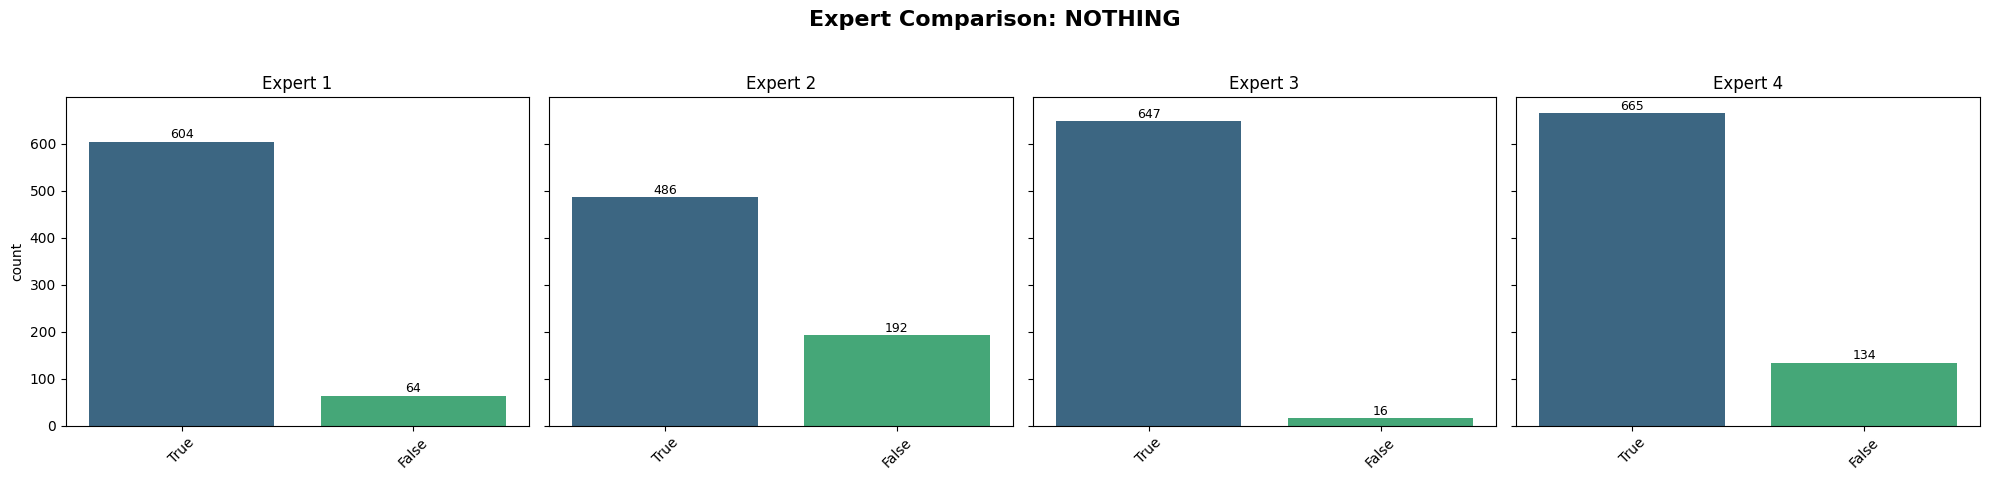

In [7]:
# 1. Define the feature groups (stubs)
expert_stubs = [
    'quality', 'diagnosis', 'cough_type', 'severity', 
    'dyspnea', 'wheezing', 'stridor', 'choking', 'congestion', 'nothing'
]

# 2. Iterate through each feature type to create a comparative row
for stub in expert_stubs:
    # Identify existing columns for this stub (e.g., quality_1, quality_2...)
    cols = [f"{stub}_{i}" for i in range(1, 5) if f"{stub}_{i}" in df_expert.columns]
    
    if not cols:
        continue
        
    # Create a 1x4 grid for the 4 experts
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    fig.suptitle(f'Expert Comparison: {stub.replace("_", " ").upper()}', fontsize=16, fontweight='bold')

    # Determine a consistent order for the X-axis across all 4 plots
    # This makes visual comparison much easier
    all_values = pd.concat([df_expert[c] for c in cols]).dropna()
    if all_values.empty:
        plt.close(fig)
        continue
    consistent_order = all_values.value_counts().index

    for i, col in enumerate(cols):
        sns.countplot(data=df_expert, x=col, ax=axes[i], order=consistent_order, palette='viridis')
        axes[i].set_title(f'Expert {i+1}')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Add count labels on top of bars for precision
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_height())}', 
                             (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='center', xytext=(0, 5), 
                             textcoords='offset points', fontsize=9)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

The overall difference in distribution for e.g. quality or diagnosis prove the subjectivity of the experts labels. Therefore its best to merge all expert labels together and use the merged base as the ground truth to remove some subjectivity

##### status vs. diagnosis

--- User Status vs. Expert Diagnoses (Row percentages) ---
expert_diagnosis  COVID-19  healthy_cough  lower_infection  \
status                                                       
COVID-19             20.17          25.07            19.45   
healthy              19.26          23.75            20.15   
symptomatic          19.82          16.63            27.79   

expert_diagnosis  obstructive_disease  upper_infection  
status                                                  
COVID-19                         7.06            28.24  
healthy                          6.42            30.42  
symptomatic                      7.57            28.19  


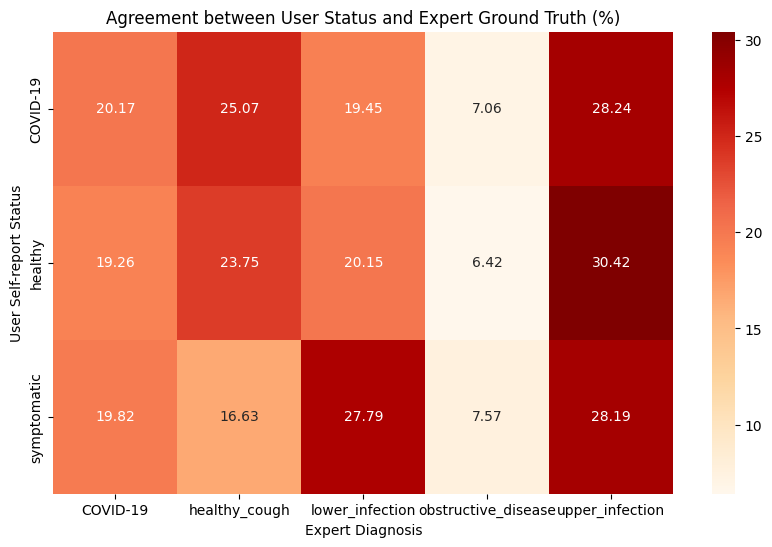

In [8]:
# Define expert diagnosis columns
diag_cols = [f'diagnosis_{i}' for i in range(1, 5) if f'diagnosis_{i}' in df_expert.columns]

# Melt the dataframe to compare User Status against any Expert Diagnosis given
df_melted = df_expert.melt(id_vars=['status'], value_vars=diag_cols, 
                           value_name='expert_diagnosis').dropna(subset=['expert_diagnosis'])

# Create the comparison table
expert_comparison = pd.crosstab(df_melted['status'], df_melted['expert_diagnosis'], 
                                 normalize='index') * 100

print("--- User Status vs. Expert Diagnoses (Row percentages) ---")
print(expert_comparison.round(2))

# Visualize the discrepancy
plt.figure(figsize=(10, 6))
sns.heatmap(expert_comparison, annot=True, cmap='OrRd', fmt='.2f')
plt.title('Agreement between User Status and Expert Ground Truth (%)')
plt.xlabel('Expert Diagnosis')
plt.ylabel('User Self-report Status')
plt.show()

There is a significant discreptancy between the users self assigned medical status and the experts diagnosis. It can be concluded that the status column might not hold any predictive power as its purely based off an individuals view.

##### Compare status & expert label against cough_detected
I suspect that a higher cough_detected score might indicate a clearer cough sound which in turn would make it easier for an expert to classify the sound correctly. This assumption is compared against the self reported status by the users

--- Cough Detected Score: Match vs. Mismatch ---
            mean  median     std  count
is_match                               
False     0.9552  0.9751  0.0479   2447
True      0.9529  0.9764  0.0511    325


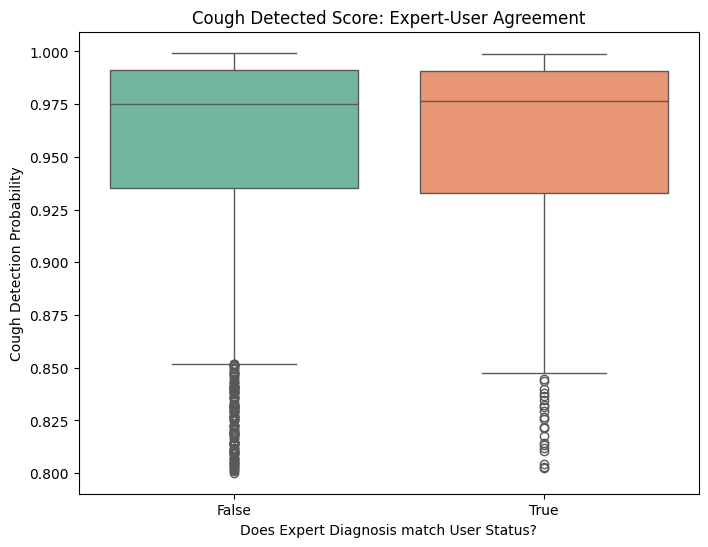

In [9]:
# 1. Map user status to expert diagnosis terms
label_map = {
    'healthy': 'healthy_cough',
    'symptomatic': 'symptomatic_cough',
    'COVID-19': 'COVID-19'
}

# 2. Extract pairs of user status and expert diagnoses
diag_cols = [f'diagnosis_{i}' for i in range(1, 5) if f'diagnosis_{i}' in df_expert.columns]
df_compare = df_expert.melt(
    id_vars=['uuid', 'status', 'cough_detected'], 
    value_vars=diag_cols, 
    value_name='expert_diagnosis'
).dropna(subset=['expert_diagnosis'])

# 3. Determine if they match
df_compare['is_match'] = df_compare.apply(
    lambda x: label_map.get(x['status']) == x['expert_diagnosis'], axis=1
)

# 4. Calculate statistics
stats = df_compare.groupby('is_match')['cough_detected'].agg(['mean', 'median', 'std', 'count'])
print("--- Cough Detected Score: Match vs. Mismatch ---")
print(stats.round(4))

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_compare, x='is_match', y='cough_detected', palette='Set2')
plt.title('Cough Detected Score: Expert-User Agreement')
plt.xlabel('Does Expert Diagnosis match User Status?')
plt.ylabel('Cough Detection Probability')
plt.show()

This shows us that there is no correlation between the cough_detected value and the classification by the experts nor any relation to the user reported status. Therefore its safe to assume that the experts classification is medically based.

#### Audio files analysis

##### Select examplary audio files
I want two samples each for these parameters:
- golden (patient & expert say COVID)
- dissociative (patient says healthy, expert says COVID)
- severity (mild)
- severity (severe)

In [ ]:
df_high_qual = df_expert[df_expert['cough_detected'] >= 0.95]

# golden samples
golden_mask = (df_high_qual['status'] == 'COVID-19') & (
    (df_high_qual['diagnosis_1'] == 'COVID-19') | 
    (df_high_qual['diagnosis_2'] == 'COVID-19') | 
    (df_high_qual['diagnosis_3'] == 'COVID-19') | 
    (df_high_qual['diagnosis_4'] == 'COVID-19')
)
golden_samples = df_high_qual[golden_mask].head(2)

# dissociation samples (user != expert)
diss_mask = (df_high_qual['status'] == 'COVID-19') & (
    (df_high_qual['diagnosis_1'] == 'healthy_cough') | 
    (df_high_qual['diagnosis_2'] == 'healthy_cough') | 
    (df_high_qual['diagnosis_3'] == 'healthy_cough') | 
    (df_high_qual['diagnosis_4'] == 'healthy_cough')
)
dissociation_samples = df_high_qual[diss_mask].head(2)

# severe samples
sev_mask_severe = (
    (df_high_qual['severity_1'] == 'severe') | 
    (df_high_qual['severity_2'] == 'severe') | 
    (df_high_qual['severity_3'] == 'severe') | 
    (df_high_qual['severity_4'] == 'severe')
)
severity_samples_severe = df_high_qual[sev_mask_severe].head(2)
sev_mask_mild = (
    (df_high_qual['severity_1'] == 'mild') | 
    (df_high_qual['severity_2'] == 'mild') | 
    (df_high_qual['severity_3'] == 'mild') | 
    (df_high_qual['severity_4'] == 'mild')
)
severity_samples_mild = df_high_qual[sev_mask_mild].head(2)

# 3. Combine and display results
selected_samples = pd.concat([
    golden_samples.assign(category='Golden (Agree COVID)'),
    dissociation_samples.assign(category='Dissociation (User COVID/Exp Healthy)'),
    severity_samples_severe.assign(category='Extreme Severity (Severe)'),
    severity_samples_mild.assign(category='Extreme Severity (Mild)')
])

selected_samples['expert_diagnosis'] = selected_samples[
    ['diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4']
].bfill(axis=1).iloc[:, 0]

selected_samples['expert_severity'] = selected_samples[
    ['severity_1', 'severity_2', 'severity_3', 'severity_4']
].bfill(axis=1).iloc[:, 0]

print("--- Selected Audio Samples for Exploration ---")
print(selected_samples[['category', 'uuid', 'status', 'expert_diagnosis', 'cough_detected']])

--- Selected Audio Samples for Exploration ---
                                   category  \
1082                   Golden (Agree COVID)   
1186                   Golden (Agree COVID)   
476   Dissociation (User COVID/Exp Healthy)   
1187  Dissociation (User COVID/Exp Healthy)   
110               Extreme Severity (Severe)   
186               Extreme Severity (Severe)   
42                  Extreme Severity (Mild)   
70                  Extreme Severity (Mild)   

                                      uuid       status expert_diagnosis  \
1082  0837bd59-09c5-4098-afe3-4bcbfb0fb0e2     COVID-19         COVID-19   
1186  09115490-33a9-461c-9437-d7f71be057b0     COVID-19         COVID-19   
476   0379c586-c500-483c-83a6-95b63afe6931     COVID-19    healthy_cough   
1187  09126c08-5214-4723-94f1-7b654464eac0     COVID-19    healthy_cough   
110   00ce5b06-c302-4387-bbd7-86355a4a8c12  symptomatic  upper_infection   
186   01567151-7bb2-45ee-9aa8-a1332b5941ea          NaN         COVID-19 

##### Check file endings for selected audio files

In [ ]:
selected_uuids = selected_samples['uuid'].tolist()

print(f"--- File Extension Check in {audio_path} ---")
for uid in selected_uuids:
    # Find files that start with the UUID
    matches = [f for f in all_files if f.startswith(uid)]
    
    if matches:
        for m in matches:
            extension = os.path.splitext(m)[1]
            print(f"UUID: {uid} | Filename: {m} | Extension: {extension}")
    else:
        print(f"UUID: {uid} | Status: File not found in directory")

--- File Extension Check in D:/uniDev/coughvid_20211012 ---
UUID: 0837bd59-09c5-4098-afe3-4bcbfb0fb0e2 | Filename: 0837bd59-09c5-4098-afe3-4bcbfb0fb0e2.json | Extension: .json
UUID: 0837bd59-09c5-4098-afe3-4bcbfb0fb0e2 | Filename: 0837bd59-09c5-4098-afe3-4bcbfb0fb0e2.webm | Extension: .webm
UUID: 09115490-33a9-461c-9437-d7f71be057b0 | Filename: 09115490-33a9-461c-9437-d7f71be057b0.json | Extension: .json
UUID: 09115490-33a9-461c-9437-d7f71be057b0 | Filename: 09115490-33a9-461c-9437-d7f71be057b0.webm | Extension: .webm
UUID: 0379c586-c500-483c-83a6-95b63afe6931 | Filename: 0379c586-c500-483c-83a6-95b63afe6931.json | Extension: .json
UUID: 0379c586-c500-483c-83a6-95b63afe6931 | Filename: 0379c586-c500-483c-83a6-95b63afe6931.webm | Extension: .webm
UUID: 09126c08-5214-4723-94f1-7b654464eac0 | Filename: 09126c08-5214-4723-94f1-7b654464eac0.json | Extension: .json
UUID: 09126c08-5214-4723-94f1-7b654464eac0 | Filename: 09126c08-5214-4723-94f1-7b654464eac0.webm | Extension: .webm
UUID: 00ce5b

##### Plot Waveforms and spectograms

C:\Users\hbend\AppData\Local\Temp\ipykernel_18316\3711394454.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=12000)


sr: 12000


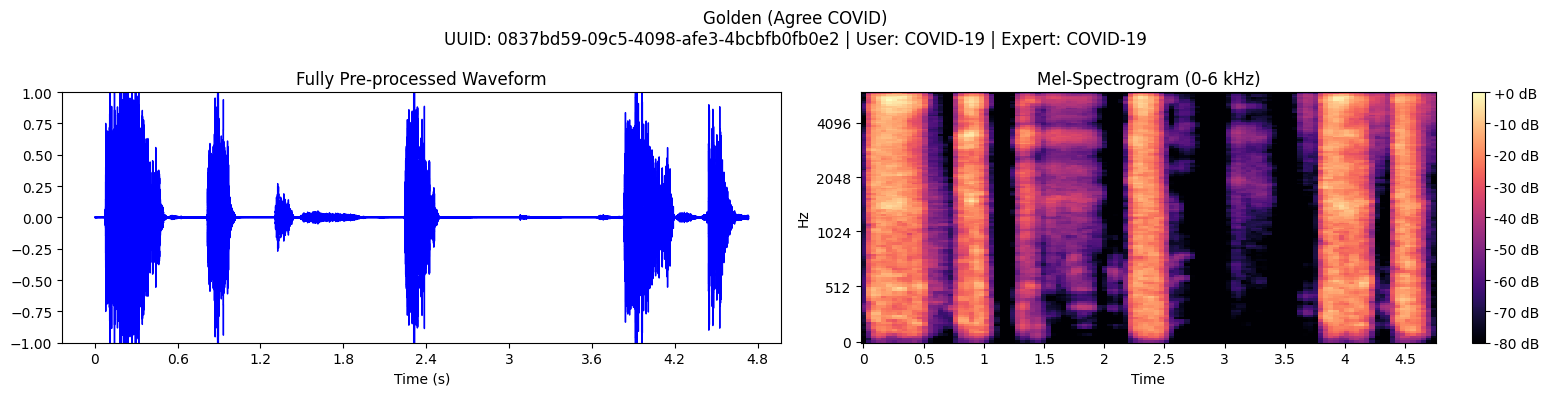

sr: 12000


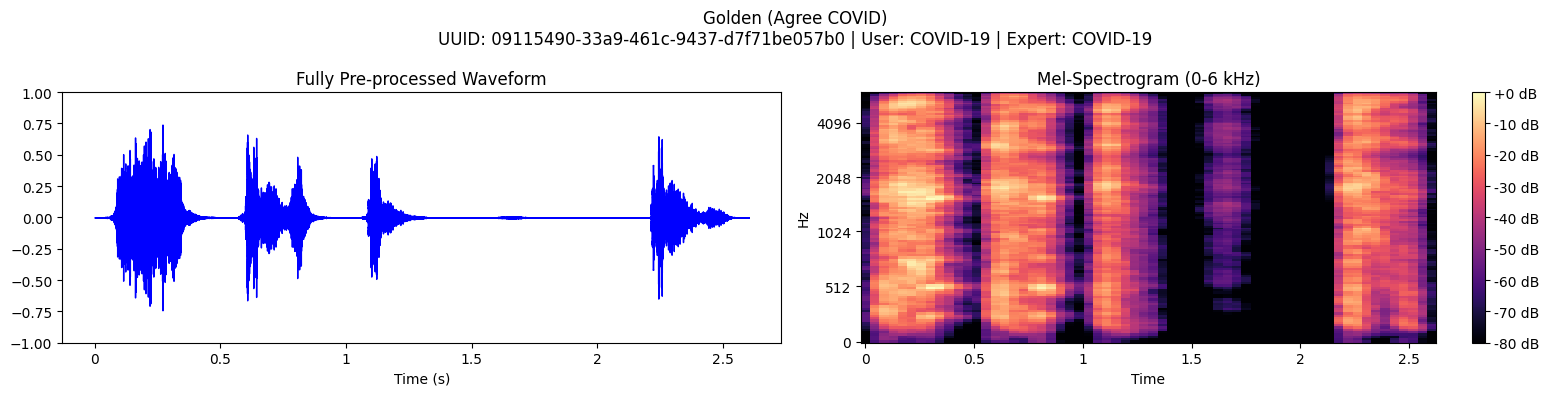

sr: 12000


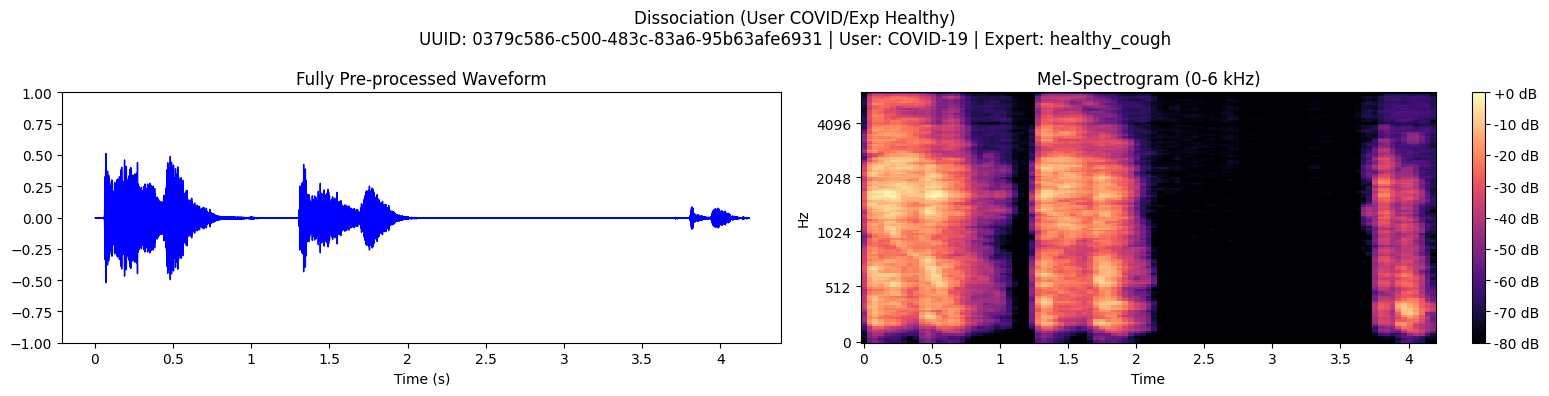

sr: 12000


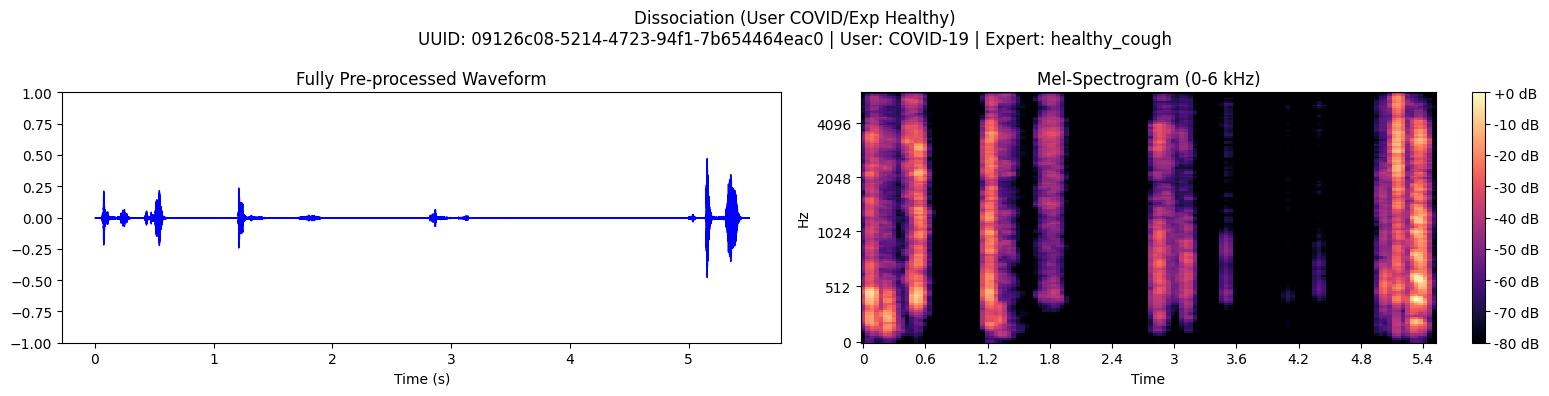

sr: 12000


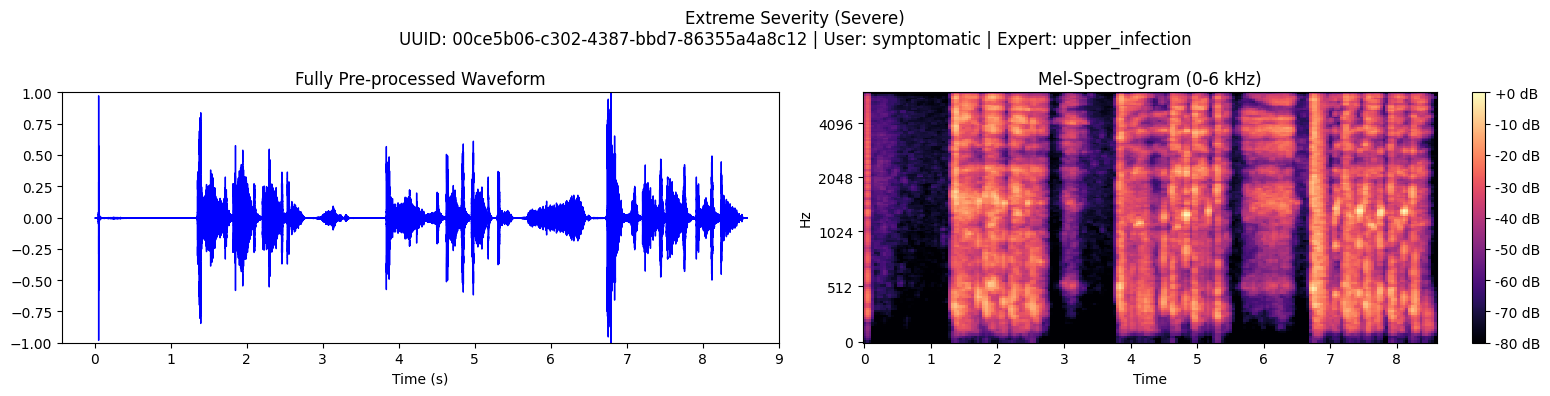

sr: 12000


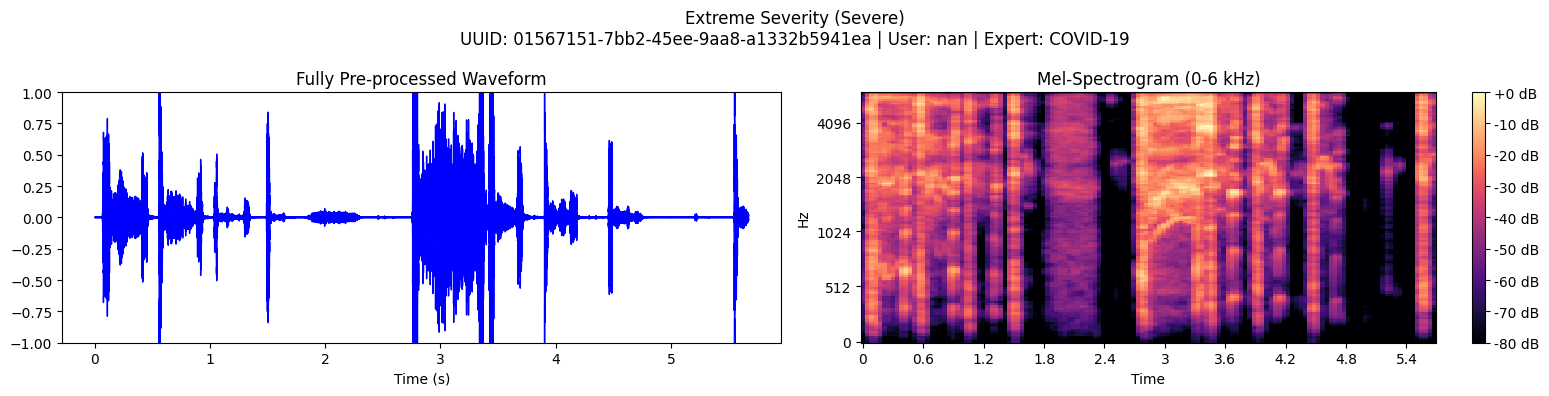

sr: 12000


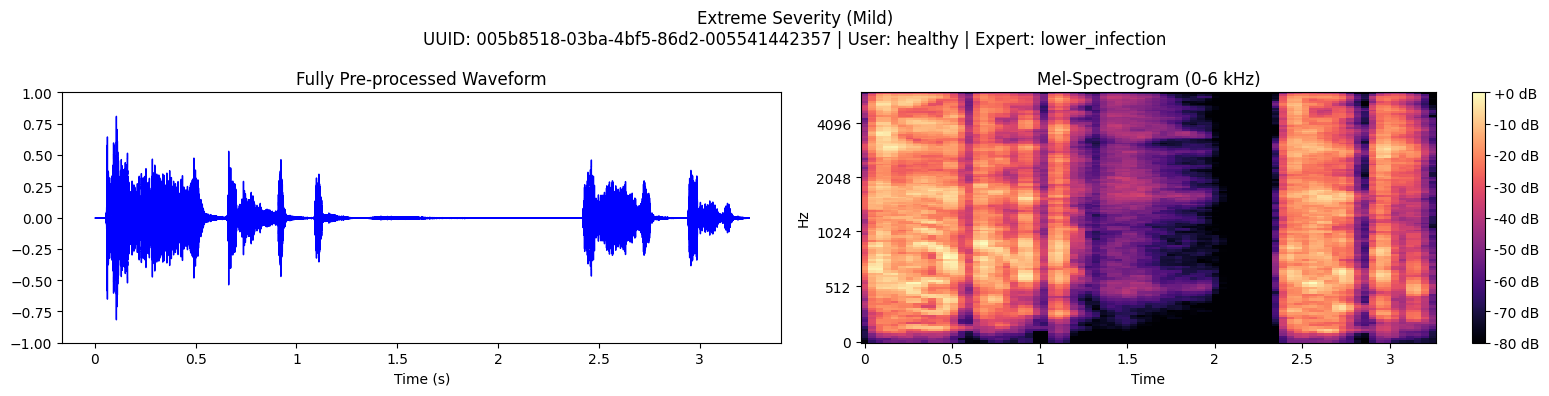

sr: 12000


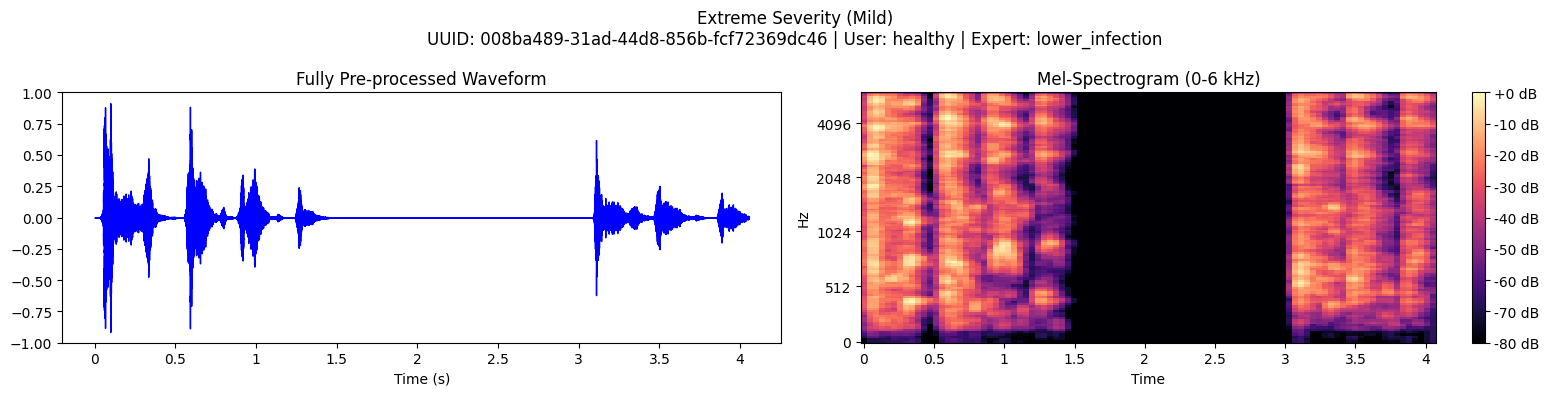

In [18]:
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    # Ensure cutoff is slightly below Nyquist to keep scipy happy
    if cutoff >= nyq:
        cutoff = nyq * 0.99
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

#def load_and_preprocess(file_path, )

def plot_cough_analysis(uuid, category, status, diagnosis):
    try:
        # load audio files
        file_name = [f for f in all_files if f.startswith(uuid) and not f.endswith('.json')][0]
        file_path = os.path.join(audio_path, file_name)

        # loading while sampling to 12kHz
        y, sr = librosa.load(file_path, sr=12000)
        print(f"sr: {sr}")

        # Amplitude Normalization
        # normalize each entry seperately based off its loudest point to a scale between 1 to -1
        # this should prevent the model form learning loudness instead of the sound itself
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))

        # Lowpass Filtering at 6kHz / 5.9kHz
        y_lowpass = butter_lowpass_filter(y, cutoff=5900, fs=sr, order=5)

        # Noise / Silence Removal
        y_trimmed, _ = librosa.effects.trim(y_lowpass, top_db=20)
        
        # flatten loudness differences between high and low frequencies using pre-emphasis
        y_filt = librosa.effects.preemphasis(y_trimmed)

        # 6. Plotting
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
        fig.suptitle(f"{category}\nUUID: {uuid} | User: {status} | Expert: {diagnosis}", fontsize=12)
        
        # Waveform Display
        librosa.display.waveshow(y_filt, sr=sr, ax=ax1, color='blue')
        ax1.set_title("Fully Pre-processed Waveform")
        ax1.set_xlabel("Time (s)")
        ax1.set_ylim(-1.0, 1.0) # Confirms amplitude normalization visually

        # Spectrogram Display (fmax altered to max allowable 6000Hz)
        S = librosa.feature.melspectrogram(y=y_filt, sr=sr, n_mels=128, fmax=6000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=6000, ax=ax2)
        ax2.set_title("Mel-Spectrogram (0-6 kHz)")
        fig.colorbar(img, ax=ax2, format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not load {uuid}: {e}")

# Run the analysis loop
for _, row in selected_samples.iterrows():
    plot_cough_analysis(row['uuid'], row['category'], row['status'], row['expert_diagnosis'])

The waveforms of COVID-19 seem to immediatly skyrocket in the beginning while healthy_coughs take more time to build up Hz. This 
The first 4 spectograms clearly show COVID-19 coughs produce more energy in the upper half (2-6kHz) compared to the healthy coughs that concentrate more up to 2.5-3 kHz. 
Severe coughs seem to concentrate heavily on the upper half of the spectograms while mild coughs fill out the whole range.
Furthermore we see in the waveforms that severe coughs have more immediate bursts after another, mild coughs rather have single burrsts with a longer decay phase.

### Data pre-processing

#### Simplify expert label column
Merge all identically named columns containing expert labels. E.g. diagnosis_1, ... , diagnosis_4

In [20]:
# Define the prefixes for the expert columns
stubs = ['quality', 'cough_type', 'dyspnea', 'wheezing', 'stridor', 
         'choking', 'congestion', 'nothing', 'diagnosis', 'severity']

# 2. Identify metadata columns to keep as identifiers
id_cols = [c for c in df_expert.columns if not any(c.endswith(f'_{i}') for i in range(1, 5))]

# Transform wide to long format
df_merged = pd.wide_to_long(
    df_expert, 
    stubnames=stubs, 
    i=id_cols, 
    j='expert_id', 
    sep='_'
).reset_index()

# Remove rows where no expert label was provided
df_merged = df_merged.dropna(subset=stubs, how='all')

print(f"Reshaped dataframe: {len(df_merged)} rows (one per expert evaluation)")
print(df_merged.columns)

Reshaped dataframe: 2808 rows (one per expert evaluation)
Index(['uuid', 'datetime', 'cough_detected', 'latitude', 'longitude', 'age',
       'gender', 'respiratory_condition', 'fever_muscle_pain', 'status',
       'status_SSL', 'expert_id', 'quality', 'cough_type', 'dyspnea',
       'wheezing', 'stridor', 'choking', 'congestion', 'nothing', 'diagnosis',
       'severity'],
      dtype='str')


#### Identify missing values
later remove all unwanted/ missing values

In [14]:
df_merged.isna().sum()

uuid                        0
datetime                    0
cough_detected              0
latitude                 1070
longitude                1070
age                       452
gender                    296
respiratory_condition     296
fever_muscle_pain         296
status                    296
status_SSL               1640
expert_id                   0
quality                     0
cough_type                 26
dyspnea                     0
wheezing                    0
stridor                     0
choking                     0
congestion                  0
nothing                     0
diagnosis                  36
severity                   26
dtype: int64

##### Check if missing age is related to other missing labels

In [21]:
nan_entries = df_merged[df_merged['age'].isna()]
nan_entries.isna().sum()

uuid                       0
datetime                   0
cough_detected             0
latitude                 171
longitude                171
age                      452
gender                   296
respiratory_condition    296
fever_muscle_pain        296
status                   296
status_SSL               302
expert_id                  0
quality                    0
cough_type                 5
dyspnea                    0
wheezing                   0
stridor                    0
choking                    0
congestion                 0
nothing                    0
diagnosis                  5
severity                   5
dtype: int64

load all datapoints where there are NaN for cough_type, diagnosis or severity into a csv to properly inspect them

In [22]:
# Filter df_merged for rows where 'diagnosis' OR 'severity' is NaN
nan_entries = df_merged[df_merged['diagnosis'].isna() | df_merged['severity'].isna() | df_merged['cough_type'].isna()]
# Display the entries
print(f"Number of entries with missing diagnosis or severity: {len(nan_entries)}")
nan_entries.to_csv('NaN_entries.csv', index=False)

Number of entries with missing diagnosis or severity: 40


#### Remove unwanted entries/features

##### Remove NaN and unuseful entries
Remove the 40 entries where some of the expert labels are NaN and on top of that remove entries where the experts classified the sound as 'no_cough'

In [32]:
initial_count = len(df_merged)
# Drop rows where any of the clinical labels are missing
df_cleaned = df_merged.dropna(subset=['diagnosis', 'severity', 'cough_type'])
# Filter out 'no_cough' entries
df_cleaned = df_cleaned[df_cleaned['quality'] != 'no_cough']

# 4. Results
final_count = len(df_cleaned)
print(f"Rows before cleaning: {initial_count}")
print(f"Rows after cleaning:  {final_count}")
print(f"Total removed:        {initial_count - final_count}")

# Update your main variable
df_merged = df_cleaned

Rows before cleaning: 2808
Rows after cleaning:  2755
Total removed:        53


##### drop unwanted features
status_SSL as it misses 50% of all values compared to self assigned status

In [ ]:
# Drop 'status_SSL' column from the dataframe
df_expert = df_expert.drop(columns=['status_SSL'])

# Verify the column is removed
print(df_expert.columns)

### Feature extraction

In [ ]:
import shutil
print(shutil.which('ffmpeg')) 
    # Should return a path, not None
import librosa

# sr=None preserves the native sampling rate
audio, sr = librosa.load('your_file.webm', sr=None)